## Load Dataset

In [42]:
import pandas as pd
data = pd.read_csv('winequality-white.csv', sep=';')
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


## Prepare Data

In [43]:
data['boolQuality'] = 0

data.loc[data['quality'] > 5, 'boolQuality'] = 1

In [44]:
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,boolQuality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,1
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,1
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,1
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,1


In [45]:
# Divide features and labels
X = data.drop(['quality', 'boolQuality'], axis=1)
y = data['boolQuality']

# Normalize data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Separate 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, train_size=0.8)

In [46]:
# Store data into DataLoaders
import torch
from torch.utils.data import TensorDataset, DataLoader

train_data = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32), 
    torch.tensor(y_train.to_numpy(), dtype=torch.float32)
)
test_data = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32), 
    torch.tensor(y_test.to_numpy(), dtype=torch.float32)
)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0], drop_last=True)

## ANN

In [47]:
import torch.nn as nn
class ANNModel(nn.Module):

    def __init__(self, actfun):
        super().__init__()

        # Input layer
        self.input = nn.Linear(11, 16)

        # Hidden Layers
        self.fc1 = nn.Linear(16, 32)
        self.fc2 = nn.Linear(32, 32)

        # Output Layer
        self.output = nn.Linear(32, 1)

        # Activation Function to pass through
        self.actfun = actfun    

    def forward(self, X):
        actfun = getattr(torch, self.actfun)
        X = actfun( self.input(X) )
        X = actfun( self.fc1(X) )
        X = actfun( self.fc2(X) )
        return self.output(X)

## Initialize metaparameters

In [48]:
# Model = ANNModel()
model = ANNModel('sigmoid')
print(model( torch.randn(10, 11) ).shape)

# Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, weight_decay=1e-4)

# Loss Function
lossfun = nn.BCEWithLogitsLoss()

torch.Size([10, 1])


## Train Model

In [49]:
import numpy as np

epochs = 1000

def trainTheModel():

    losses = torch.zeros(epochs)
    trainAcc = []
    testAcc = []

    for epochi in range(epochs):

        # ===== Train =====
        model.train()

        batchAcc = []
        batchLoss = []
        for X, y in train_loader:

            # Forward
            yHat = model(X).squeeze()
            loss = lossfun(yHat, y)

            # Back
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Metrics
            batchLoss.append(loss.item())

            batchAcc.append( 100*torch.mean(((yHat>0) == y).float()).item() )

        trainAcc.append( np.mean(batchAcc) )

        losses[epochi] = np.mean(batchLoss)
            
        # ===== Test =====
        model.eval()
        X, y = next(iter(test_loader))
        with torch.no_grad():
            yHat = model(X).squeeze()
        testAcc.append( 100*torch.mean(((yHat>0) == y).float()).item() )

    return trainAcc, testAcc, losses

In [50]:
activation_funs = ['relu', 'tanh', 'sigmoid']

trainByAct = np.zeros((epochs, len(activation_funs)))
testByAct = np.zeros((epochs, len(activation_funs)))

for ai, actfun in enumerate(activation_funs):
    model = ANNModel(actfun)
    trainByAct[:,ai], testByAct[:,ai], losses = trainTheModel()

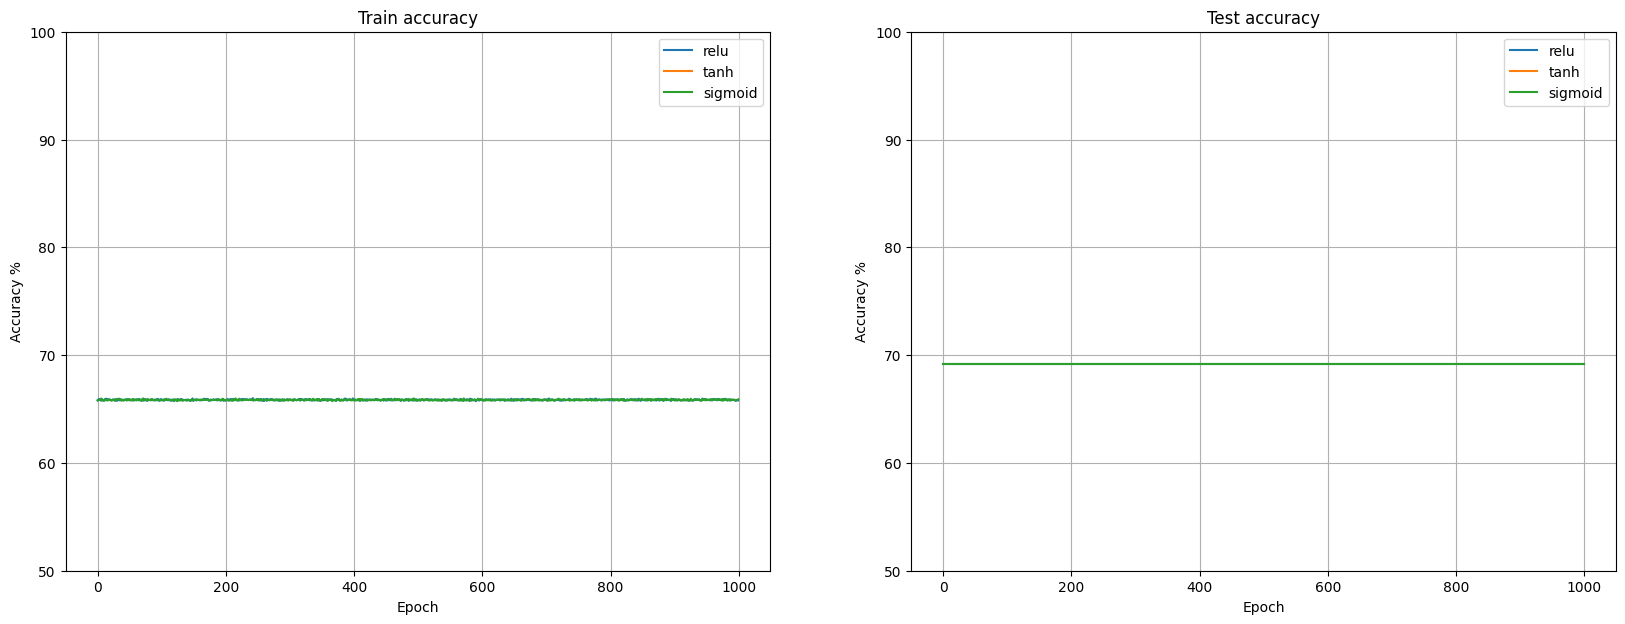

In [52]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(20, 7))

ax[0].plot(trainByAct)
ax[0].set_title('Train accuracy')
ax[1].plot(testByAct)
ax[1].set_title('Test accuracy')

for i in range(2):
    ax[i].legend(activation_funs)
    ax[i].set_xlabel('Epoch')
    ax[i].set_ylabel('Accuracy %')
    ax[i].set_ylim([50, 100])
    ax[i].grid()

plt.show()